# Carbon-Aware Hyperparameter Optimization
## Bio-Inspired Artificial Intelligence — University of Messina
### NSGA-II vs Grid Search vs Random Search

## 0. Install & Import Libraries

In [1]:
# Install required libraries
!pip install pymoo codecarbon scikit-learn pandas numpy matplotlib ucimlrepo --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from codecarbon import OfflineEmissionsTracker

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.pm import PM
from pymoo.indicators.hv import HV

from ucimlrepo import fetch_ucirepo

np.random.seed(42)

# Create output folder for CSVs
os.makedirs('results', exist_ok=True)



## 1. Data Loading & Preprocessing

In [3]:
# Load dataset
wine     = fetch_ucirepo(id=186)
X        = wine.data.features
y        = wine.data.targets
y_binary = (y.values.ravel() >= 6).astype(int)

print('Class distribution:')
print(f'  Good wine (1): {y_binary.sum()} ({y_binary.mean()*100:.1f}%)')
print(f'  Bad wine  (0): {(1-y_binary).sum()} ({(1-y_binary).mean()*100:.1f}%)')

# Three-way split: 70% train, 15% val, 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_binary, test_size=0.15, random_state=42, stratify=y_binary               #straify ensures that the proportion of classes (0s and 1s) stays approximately the same in both sets.
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=y_trainval
)

# Z-score normalization using training set statistics only
scaler           = StandardScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_val_scaled     = scaler.transform(X_val)
X_test_scaled    = scaler.transform(X_test)

# Combined train+val for final retraining after MCDM selection
X_trainval_scaled   = np.concatenate([X_train_scaled, X_val_scaled])
y_trainval_combined = np.concatenate([y_train, y_val])

print(f'\nThree-way split:')
print(f'  Train : {len(X_train_scaled)} samples ({len(X_train_scaled)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val_scaled)} samples ({len(X_val_scaled)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test_scaled)} samples ({len(X_test_scaled)/len(X)*100:.1f}%)')
print(f'  TrainVal (final): {len(X_trainval_scaled)} samples')

Class distribution:
  Good wine (1): 4113 (63.3%)
  Bad wine  (0): 2384 (36.7%)

Three-way split:
  Train : 4550 samples (70.0%)
  Val   : 972 samples (15.0%)
  Test  : 975 samples (15.0%)
  TrainVal (final): 5522 samples


## 2. Hyperparameter Search Space & Settings

In [4]:
# ── NSGA-II HYPERPARAMETER MAPPINGS ──────────────────────────────
# pymoo requires integer indices — map to actual values at evaluation
LAYERS_MAP  = [1, 2, 3, 4, 5, 6]                        # x[0]: 0-5
NEURONS_MAP = [32, 64, 128, 256, 512]                   # x[1]: 0-4
LR_MAP      = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]     # x[2]: 0-5
BATCH_MAP   = [16, 32, 64, 128, 256]                    # x[3]: 0-4

# ── NSGA-II ALGORITHM SETTINGS ───────────────────────────────────
POPULATION_SIZE = 50
N_GENERATIONS   = 30
CROSSOVER_RATE  = 0.8
MUTATION_RATE   = 0.1

# ── MCDM WEIGHTS (equal — all objectives equally important) ──────
W1, W2, W3 = 1/3, 1/3, 1/3   # error, time, CO2

# ── GRID/RANDOM SEARCH SPACE (tuples for MLPClassifier) ──────────
# MLP requires hidden_layer_sizes as tuple → pre-build all architectures
all_layers = [
    (32,),(64,),(128,),(256,),(512,),
    (32,32),(64,64),(128,128),(256,256),(512,512),
    (32,32,32),(64,64,64),(128,128,128),(256,256,256),(512,512,512),
    (32,32,32,32),(64,64,64,64),(128,128,128,128),(256,256,256,256),(512,512,512,512),
    (32,32,32,32,32),(64,64,64,64,64),(128,128,128,128,128),(256,256,256,256,256),(512,512,512,512,512),
    (32,32,32,32,32,32),(64,64,64,64,64,64),(128,128,128,128,128,128),(256,256,256,256,256,256),(512,512,512,512,512,512)
]
all_lrs     = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
all_batches = [16, 32, 64, 128, 256]

total = len(all_layers) * len(all_lrs) * len(all_batches)

print('Search space:')
print(f'  Architectures : {len(all_layers)}')
print(f'  Learning rates: {len(all_lrs)}')
print(f'  Batch sizes   : {len(all_batches)}')
print(f'  Total combos  : {total}')
print(f'\nVerification — NSGA-II vs Grid Search:')
print(f'  NSGA-II space : {len(LAYERS_MAP)*len(NEURONS_MAP)*len(LR_MAP)*len(BATCH_MAP)}')
print(f'  Grid Search   : {total}')
print(f'  Match         : {total == len(LAYERS_MAP)*len(NEURONS_MAP)*len(LR_MAP)*len(BATCH_MAP)}')

Search space:
  Architectures : 30
  Learning rates: 6
  Batch sizes   : 5
  Total combos  : 900

Verification — NSGA-II vs Grid Search:
  NSGA-II space : 900
  Grid Search   : 900
  Match         : True


## 3. Helper Functions

In [5]:
def compute_pareto_front(results_df):
    """Extract non-dominated solutions from evaluated configurations."""
    costs = results_df[['error', 'time_s', 'co2_kg']].values
    n     = len(costs)
    pareto_mask = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j:
                if all(costs[j] <= costs[i]) and any(costs[j] < costs[i]):
                    pareto_mask[i] = False
                    break
    return results_df[pareto_mask].copy(), costs[pareto_mask]


def normalize_pareto(pareto_F, error_min, error_max,
                     time_min, time_max, co2_min, co2_max):
    """Min-max normalize Pareto front using global ranges.
    Ensures all methods compared on same scale.
    W1=W2=W3=1/3 meaningful only after normalization.
    """
    def minmax(v, vmin, vmax):
        if vmax == vmin:
            return np.zeros_like(v)
        return (v - vmin) / (vmax - vmin)
    return np.column_stack([
        minmax(pareto_F[:,0], error_min, error_max),
        minmax(pareto_F[:,1], time_min,  time_max),
        minmax(pareto_F[:,2], co2_min,   co2_max)
    ])


def pick_best_from_pareto(pareto_df, pareto_F_norm):
    """Apply MCDM weighted fitness to normalized Pareto front.
    Equal weights W1=W2=W3=1/3 reflect equal importance
    of accuracy, speed, and carbon efficiency.
    Lower fitness = better solution.
    """
    fitness_scores = (
        W1 * pareto_F_norm[:,0] +
        W2 * pareto_F_norm[:,1] +
        W3 * pareto_F_norm[:,2]
    )
    best_idx = np.argmin(fitness_scores)
    return pareto_df.iloc[best_idx], float(fitness_scores[best_idx])


def maximum_spread(F):
    """Measures how widely Pareto front extends across objective space.
    Higher = more diverse trade-off solutions.
    """
    return np.sqrt(np.sum((F.max(axis=0) - F.min(axis=0))**2))


print('Helper functions defined!')

Helper functions defined!


## 4. NSGA-II — Multi-Objective HPO



In [6]:
# ── EVALUATION CACHE ──────────────────────────────────────────────
# Prevents redundant MLP trainings when NSGA-II revisits configs
evaluation_cache = {}
all_results      = []

class HyperparameterOptimizationProblem(Problem):

    def __init__(self):
        super().__init__(
            n_var=4,       # 4 hyperparameters
            n_obj=3,       # 3 objectives: error, time, CO2
            n_constr=0,    # no constraints
            xl=np.array([0, 0, 0, 0]),   # lower bounds (indices)
            xu=np.array([5, 4, 5, 4]),   # upper bounds (indices)
            vtype=int      # integer encoding
        )

    def _evaluate(self, X_pop, out, *args, **kwargs):
        objectives  = []
        cache_hits  = 0
        cache_miss  = 0

        for x in X_pop:
            key = (int(x[0]), int(x[1]), int(x[2]), int(x[3]))

            if key in evaluation_cache:
                objectives.append(evaluation_cache[key])
                cache_hits += 1
            else:
                n_layers  = LAYERS_MAP[key[0]]
                n_neurons = NEURONS_MAP[key[1]]
                lr        = LR_MAP[key[2]]
                batch     = BATCH_MAP[key[3]]
                layers    = tuple([n_neurons] * n_layers)

                mlp = MLPClassifier(
                    hidden_layer_sizes=layers,
                    learning_rate_init=lr,
                    batch_size=batch,
                    max_iter=30,
                    random_state=42,
                    early_stopping=False
                )

                tracker = OfflineEmissionsTracker(
                    log_level='error',
                    save_to_file=False,
                    country_iso_code='ITA'
                )
                tracker.start()
                t0        = time.time()
                mlp.fit(X_train_scaled, y_train)
                elapsed   = time.time() - t0
                emissions = tracker.stop() or 0.0

                val_acc = accuracy_score(y_val, mlp.predict(X_val_scaled))
                error   = 1.0 - val_acc
                result  = [error, elapsed, emissions]

                evaluation_cache[key] = result
                all_results.append({
                    'n_layers'     : n_layers,
                    'n_neurons'    : n_neurons,
                    'learning_rate': lr,
                    'batch_size'   : batch,
                    'val_accuracy' : val_acc,
                    'error'        : error,
                    'time_s'       : elapsed,
                    'co2_kg'       : emissions,
                })
                objectives.append(result)
                cache_miss += 1

        print(f'  Gen: {cache_miss} new, {cache_hits} cached '
              f'(total unique: {len(evaluation_cache)})')
        out['F'] = np.array(objectives)

print('Problem class defined!')

Problem class defined!


In [7]:
# ── RUN NSGA-II ───────────────────────────────────────────────────
evaluation_cache = {}
all_results      = []

problem   = HyperparameterOptimizationProblem()
algorithm = NSGA2(
    pop_size=POPULATION_SIZE,
    sampling=IntegerRandomSampling(),
    crossover=TwoPointCrossover(prob=CROSSOVER_RATE),
    mutation=PM(prob=MUTATION_RATE, eta=3, vtype=int),
    eliminate_duplicates=True
)
termination = get_termination('n_gen', N_GENERATIONS)

print(f'NSGA-II starting: pop={POPULATION_SIZE}, gen={N_GENERATIONS}')
ga_start = time.time()

result = minimize(problem, algorithm, termination, seed=42, verbose=False)

ga_total_time  = time.time() - ga_start
nsga_total_co2 = sum(r['co2_kg'] for r in all_results)

# Build Pareto DataFrame
pareto_rows = []
for i in range(len(result.F)):
    x = result.X[i]
    f = result.F[i]
    pareto_rows.append({
        'n_layers'      : LAYERS_MAP[int(x[0])],
        'n_neurons'     : NEURONS_MAP[int(x[1])],
        'learning_rate' : LR_MAP[int(x[2])],
        'batch_size'    : BATCH_MAP[int(x[3])],
        'error'         : f[0],
        'time_s'        : f[1],
        'co2_kg'        : f[2],
    })
nsga_pareto_df = pd.DataFrame(pareto_rows)
nsga_pareto_F  = result.F
nsga_pareto_X  = result.X

# Save all evaluations and Pareto front to CSV
pd.DataFrame(all_results).to_csv('results/nsga2_all_evals.csv', index=False)
nsga_pareto_df.to_csv('results/nsga2_pareto.csv', index=False)
pd.DataFrame([{
    'total_time_min' : ga_total_time/60,
    'total_co2_kg'   : nsga_total_co2,
    'total_evals'    : len(all_results),
    'unique_evals'   : len(evaluation_cache),
    'pareto_size'    : len(nsga_pareto_F),
}]).to_csv('results/nsga2_summary.csv', index=False)

print(f'\nNSGA-II COMPLETE')
print(f'  Time         : {ga_total_time/60:.2f} min')
print(f'  Total CO2    : {nsga_total_co2:.6f} kg')
print(f'  Total evals  : {len(all_results)}')
print(f'  Unique evals : {len(evaluation_cache)}')
print(f'  Coverage     : {len(evaluation_cache)/900*100:.1f}%')
print(f'  Pareto size  : {len(nsga_pareto_F)}')
print(f'\nSaved: results/nsga2_all_evals.csv')
print(f'Saved: results/nsga2_pareto.csv')
print(f'Saved: results/nsga2_summary.csv')

[codecarbon INFO @ 19:02:55] offline tracker init
[codecarbon WARNING @ 19:02:55] Multiple instances of codecarbon are allowed to run at the same time.


NSGA-II starting: pop=50, gen=30
  Gen: 49 new, 0 cached (total unique: 49)
  Gen: 50 new, 0 cached (total unique: 99)
  Gen: 47 new, 3 cached (total unique: 146)
  Gen: 40 new, 10 cached (total unique: 186)
  Gen: 34 new, 16 cached (total unique: 220)
  Gen: 27 new, 23 cached (total unique: 247)
  Gen: 23 new, 27 cached (total unique: 270)
  Gen: 24 new, 26 cached (total unique: 294)
  Gen: 14 new, 36 cached (total unique: 308)
  Gen: 19 new, 31 cached (total unique: 327)
  Gen: 11 new, 39 cached (total unique: 338)
  Gen: 10 new, 40 cached (total unique: 348)
  Gen: 12 new, 38 cached (total unique: 360)
  Gen: 6 new, 44 cached (total unique: 366)
  Gen: 8 new, 42 cached (total unique: 374)
  Gen: 8 new, 42 cached (total unique: 382)
  Gen: 6 new, 44 cached (total unique: 388)
  Gen: 5 new, 45 cached (total unique: 393)
  Gen: 5 new, 45 cached (total unique: 398)
  Gen: 9 new, 41 cached (total unique: 407)
  Gen: 4 new, 46 cached (total unique: 411)
  Gen: 1 new, 49 cached (total uniq

## 5. Grid Search — Exhaustive Baseline


In [8]:
from itertools import product

print('Running Grid Search (900 combinations)...')
print('-' * 60)

grid_results = []
grid_start   = time.time()
combinations = list(product(all_layers, all_lrs, all_batches))

for i, (layers, lr, batch) in enumerate(combinations):
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        learning_rate_init=lr,
        batch_size=batch,
        max_iter=30,
        random_state=42,
        early_stopping=False
    )
    tracker = OfflineEmissionsTracker(
        log_level='error', save_to_file=False, country_iso_code='ITA'
    )
    tracker.start()
    t0      = time.time()
    mlp.fit(X_train_scaled, y_train)
    elapsed = time.time() - t0
    co2     = tracker.stop() or 0.0

    val_acc = accuracy_score(y_val, mlp.predict(X_val_scaled))
    error   = 1 - val_acc

    grid_results.append({
        'layers' : str(layers),
        'lr'     : lr,
        'batch'  : batch,
        'val_acc': val_acc,
        'error'  : error,
        'time_s' : elapsed,
        'co2_kg' : co2,
    })

    if (i+1) % 100 == 0:
        print(f'  Progress: {i+1}/{len(combinations)}')

grid_total_time = time.time() - grid_start
grid_total_co2  = sum(r['co2_kg'] for r in grid_results)

# Build Pareto front
grid_df                       = pd.DataFrame(grid_results)
grid_pareto_df, grid_pareto_F = compute_pareto_front(grid_df)

# Save to CSV
grid_df.to_csv('results/grid_all_evals.csv', index=False)
grid_pareto_df.to_csv('results/grid_pareto.csv', index=False)
pd.DataFrame([{
    'total_time_min': grid_total_time/60,
    'total_co2_kg'  : grid_total_co2,
    'total_evals'   : len(grid_results),
    'pareto_size'   : len(grid_pareto_df),
}]).to_csv('results/grid_summary.csv', index=False)

print(f'\nGrid Search COMPLETE')
print(f'  Evaluations: {len(grid_results)}')
print(f'  Pareto size: {len(grid_pareto_df)}')
print(f'  Total time : {grid_total_time/60:.2f} min')
print(f'  Total CO2  : {grid_total_co2:.6f} kg')
print(f'\nSaved: results/grid_all_evals.csv')
print(f'Saved: results/grid_pareto.csv')
print(f'Saved: results/grid_summary.csv')

Running Grid Search (900 combinations)...
------------------------------------------------------------
  Progress: 100/900
  Progress: 200/900
  Progress: 300/900
  Progress: 400/900
  Progress: 500/900
  Progress: 600/900
  Progress: 700/900
  Progress: 800/900
  Progress: 900/900

Grid Search COMPLETE
  Evaluations: 900
  Pareto size: 14
  Total time : 421.33 min
  Total CO2  : 0.035094 kg

Saved: results/grid_all_evals.csv
Saved: results/grid_pareto.csv
Saved: results/grid_summary.csv


## 6. Random Search — Efficient Baseline

In [9]:
import random
import time
random.seed(42)

print('Running Random Search (100 combinations)...')
print('-' * 60)

all_combinations    = list(product(all_layers, all_lrs, all_batches))
random.shuffle(all_combinations)
random_combinations = all_combinations[:100]

rand_results = []
rand_start   = time.time()

for i, (layers, lr, batch) in enumerate(random_combinations):
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        learning_rate_init=lr,
        batch_size=batch,
        max_iter=30,
        random_state=42,
        early_stopping=False
    )
    tracker = OfflineEmissionsTracker(
        log_level='error', save_to_file=False, country_iso_code='ITA'
    )
    tracker.start()
    t0      = time.time()
    mlp.fit(X_train_scaled, y_train)
    elapsed = time.time() - t0
    co2     = tracker.stop() or 0.0

    val_acc = accuracy_score(y_val, mlp.predict(X_val_scaled))
    error   = 1 - val_acc

    rand_results.append({
        'layers' : str(layers),
        'lr'     : lr,
        'batch'  : batch,
        'val_acc': val_acc,
        'error'  : error,
        'time_s' : elapsed,
        'co2_kg' : co2,
    })

    print(f'  Combo {i+1:03d}/100 | val_acc={val_acc*100:.1f}% | '
          f'time={elapsed:.1f}s | co2={co2:.8f}kg')

rand_total_time = time.time() - rand_start
rand_total_co2  = sum(r['co2_kg'] for r in rand_results)

# Build Pareto front
rand_df                       = pd.DataFrame(rand_results)
rand_pareto_df, rand_pareto_F = compute_pareto_front(rand_df)

# Save to CSV
rand_df.to_csv('results/rand_all_evals.csv', index=False)
rand_pareto_df.to_csv('results/rand_pareto.csv', index=False)
pd.DataFrame([{
    'total_time_min': rand_total_time/60,
    'total_co2_kg'  : rand_total_co2,
    'total_evals'   : len(rand_results),
    'pareto_size'   : len(rand_pareto_df),
}]).to_csv('results/rand_summary.csv', index=False)

print(f'\nRandom Search COMPLETE')
print(f'  Evaluations: {len(rand_results)}')
print(f'  Pareto size: {len(rand_pareto_df)}')
print(f'  Total time : {rand_total_time/60:.2f} min')
print(f'  Total CO2  : {rand_total_co2:.6f} kg')
print(f'\nSaved: results/rand_all_evals.csv')
print(f'Saved: results/rand_pareto.csv')
print(f'Saved: results/rand_summary.csv')

Running Random Search (100 combinations)...
------------------------------------------------------------
  Combo 001/100 | val_acc=77.1% | time=0.6s | co2=0.00000350kg
  Combo 002/100 | val_acc=80.1% | time=116.1s | co2=0.00017609kg
  Combo 003/100 | val_acc=80.2% | time=24.3s | co2=0.00004155kg
  Combo 004/100 | val_acc=79.1% | time=0.3s | co2=0.00000315kg
  Combo 005/100 | val_acc=80.0% | time=20.9s | co2=0.00003625kg
  Combo 006/100 | val_acc=81.4% | time=60.2s | co2=0.00010999kg
  Combo 007/100 | val_acc=80.8% | time=6.9s | co2=0.00001351kg
  Combo 008/100 | val_acc=79.8% | time=24.6s | co2=0.00004027kg
  Combo 009/100 | val_acc=78.8% | time=0.8s | co2=0.00000387kg
  Combo 010/100 | val_acc=78.6% | time=2.6s | co2=0.00000588kg
  Combo 011/100 | val_acc=78.4% | time=0.4s | co2=0.00000322kg
  Combo 012/100 | val_acc=77.0% | time=8.8s | co2=0.00001657kg
  Combo 013/100 | val_acc=78.1% | time=0.1s | co2=0.00000290kg
  Combo 014/100 | val_acc=80.3% | time=2.0s | co2=0.00000585kg
  Combo

## 7. Load Results From CSV (Run This After Kernel Restart)

In [10]:
import ast

# ── LOAD ALL RESULTS FROM CSV ─────────────────────────────────────
# NSGA-II
all_results_df  = pd.read_csv('results/nsga2_all_evals.csv')
nsga_pareto_df  = pd.read_csv('results/nsga2_pareto.csv')
nsga_summary    = pd.read_csv('results/nsga2_summary.csv')
all_results     = all_results_df.to_dict('records')
nsga_pareto_F   = nsga_pareto_df[['error','time_s','co2_kg']].values
ga_total_time   = nsga_summary['total_time_min'].values[0] * 60
nsga_total_co2  = nsga_summary['total_co2_kg'].values[0]

# Grid Search
grid_df         = pd.read_csv('results/grid_all_evals.csv')
grid_pareto_df  = pd.read_csv('results/grid_pareto.csv')
grid_summary    = pd.read_csv('results/grid_summary.csv')
grid_results    = grid_df.to_dict('records')
grid_pareto_F   = grid_pareto_df[['error','time_s','co2_kg']].values
grid_total_time = grid_summary['total_time_min'].values[0] * 60
grid_total_co2  = grid_summary['total_co2_kg'].values[0]

# Random Search
rand_df         = pd.read_csv('results/rand_all_evals.csv')
rand_pareto_df  = pd.read_csv('results/rand_pareto.csv')
rand_summary    = pd.read_csv('results/rand_summary.csv')
rand_results    = rand_df.to_dict('records')
rand_pareto_F   = rand_pareto_df[['error','time_s','co2_kg']].values
rand_total_time = rand_summary['total_time_min'].values[0] * 60
rand_total_co2  = rand_summary['total_co2_kg'].values[0]

# Restore layers column as tuples for Grid/Random
grid_df['layers_tuple'] = grid_df['layers'].apply(ast.literal_eval)
rand_df['layers_tuple'] = rand_df['layers'].apply(ast.literal_eval)

print('All results loaded from CSV!')
print(f'  NSGA-II : {len(all_results)} evals, {len(nsga_pareto_F)} Pareto')
print(f'  Grid    : {len(grid_results)} evals, {len(grid_pareto_F)} Pareto')
print(f'  Random  : {len(rand_results)} evals, {len(rand_pareto_F)} Pareto')

All results loaded from CSV!
  NSGA-II : 431 evals, 12 Pareto
  Grid    : 900 evals, 14 Pareto
  Random  : 100 evals, 3 Pareto


## 8. Hypervolume Comparison

In [11]:
print('=' * 60)
print('FAIR HYPERVOLUME COMPARISON')
print('=' * 60)

# Step A — Global normalization ranges from ALL evaluations
all_F = np.vstack([
    np.array([[r['error'], r['time_s'], r['co2_kg']] for r in all_results]),
    grid_df[['error', 'time_s', 'co2_kg']].values,
    rand_df[['error', 'time_s', 'co2_kg']].values
])

error_min, error_max = all_F[:,0].min(), all_F[:,0].max()
time_min,  time_max  = all_F[:,1].min(), all_F[:,1].max()
co2_min,   co2_max   = all_F[:,2].min(), all_F[:,2].max()

print(f'\nStep A — Normalization ranges ({len(all_F)} evaluations):')
print(f'  error : {error_min:.4f} to {error_max:.4f}')
print(f'  time  : {time_min:.2f}s to {time_max:.2f}s')
print(f'  CO2   : {co2_min:.8f} to {co2_max:.8f}kg')

# Step B — Normalize Pareto fronts and clip to [0,1]
nsga_F_norm = np.clip(normalize_pareto(
    nsga_pareto_F, error_min, error_max, time_min, time_max, co2_min, co2_max), 0, 1)
grid_F_norm = np.clip(normalize_pareto(
    grid_pareto_F, error_min, error_max, time_min, time_max, co2_min, co2_max), 0, 1)
rand_F_norm = np.clip(normalize_pareto(
    rand_pareto_F, error_min, error_max, time_min, time_max, co2_min, co2_max), 0, 1)

print(f'\nStep B — After clipping to [0,1]:')
for name, F in [('NSGA-II', nsga_F_norm), ('Grid', grid_F_norm), ('Random', rand_F_norm)]:
    status = '' if F.min() >= 0 and F.max() <= 1 else ''
    print(f'  {status} {name}: [{F.min():.4f}, {F.max():.4f}]')

# Step C — Compute HV with ref=[1.1,1.1,1.1]
# Max possible HV = 1.1^3 = 1.331 → values >1 are valid
ref_point    = np.array([1.1, 1.1, 1.1])
hv_indicator = HV(ref_point=ref_point)

nsga_hv = float(hv_indicator(nsga_F_norm))
grid_hv = float(hv_indicator(grid_F_norm))
rand_hv = float(hv_indicator(rand_F_norm))

print(f'\nStep C — Hypervolume (ref=[1.1,1.1,1.1], max={1.1**3:.4f}):')
print(f'  NSGA-II      : {nsga_hv:.6f}')
print(f'  Grid Search  : {grid_hv:.6f}')
print(f'  Random Search: {rand_hv:.6f}')

# Maximum Spread
nsga_ms = maximum_spread(nsga_F_norm)
grid_ms = maximum_spread(grid_F_norm)
rand_ms = maximum_spread(rand_F_norm)

print(f'\nMaximum Spread (higher=better):')
print(f'  NSGA-II      : {nsga_ms:.6f}')
print(f'  Grid Search  : {grid_ms:.6f}')
print(f'  Random Search: {rand_ms:.6f}')

FAIR HYPERVOLUME COMPARISON

Step A — Normalization ranges (1431 evaluations):
  error : 0.1780 to 0.3673
  time  : 0.11s to 420.09s
  CO2   : 0.00000242 to 0.00063668kg

Step B — After clipping to [0,1]:
   NSGA-II: [0.0000, 0.2554]
   Grid: [0.0000, 0.2899]
   Random: [0.0000, 0.1902]

Step C — Hypervolume (ref=[1.1,1.1,1.1], max=1.3310):
  NSGA-II      : 1.309555
  Grid Search  : 1.320416
  Random Search: 1.309029

Maximum Spread (higher=better):
  NSGA-II      : 0.240569
  Grid Search  : 0.480036
  Random Search: 0.175394


## 9. MCDM Solution Selection & Final Comparison

In [12]:
print('=' * 60)
print(f'MCDM — Equal weights W1=W2=W3={W1:.4f}')
print('=' * 60)

# Select best from each Pareto front
nsga_best, nsga_best_fitness = pick_best_from_pareto(nsga_pareto_df, nsga_F_norm)
grid_best, grid_best_fitness = pick_best_from_pareto(grid_pareto_df, grid_F_norm)
rand_best, rand_best_fitness = pick_best_from_pareto(rand_pareto_df, rand_F_norm)

print(f'\n  NSGA-II      fitness: {nsga_best_fitness:.4f}')
print(f'  Grid Search  fitness: {grid_best_fitness:.4f}')
print(f'  Random Search fitness: {rand_best_fitness:.4f}')

# Retrain best NSGA-II config on Train+Val → Test
best_mlp = MLPClassifier(
    hidden_layer_sizes=tuple([int(nsga_best['n_neurons'])] * int(nsga_best['n_layers'])),
    learning_rate_init=float(nsga_best['learning_rate']),
    batch_size=int(nsga_best['batch_size']),
    max_iter=100, random_state=42
)
best_mlp.fit(X_trainval_scaled, y_trainval_combined)
ga_best_acc = accuracy_score(y_test, best_mlp.predict(X_test_scaled))

# Retrain best Grid Search config
grid_layers = ast.literal_eval(grid_best['layers']) if isinstance(grid_best['layers'], str) else grid_best['layers']
grid_best_mlp = MLPClassifier(
    hidden_layer_sizes=grid_layers,
    learning_rate_init=float(grid_best['lr']),
    batch_size=int(grid_best['batch']),
    max_iter=100, random_state=42
)
grid_best_mlp.fit(X_trainval_scaled, y_trainval_combined)
grid_test_acc = accuracy_score(y_test, grid_best_mlp.predict(X_test_scaled))

# Retrain best Random Search config
rand_layers = ast.literal_eval(rand_best['layers']) if isinstance(rand_best['layers'], str) else rand_best['layers']
rand_best_mlp = MLPClassifier(
    hidden_layer_sizes=rand_layers,
    learning_rate_init=float(rand_best['lr']),
    batch_size=int(rand_best['batch']),
    max_iter=100, random_state=42
)
rand_best_mlp.fit(X_trainval_scaled, y_trainval_combined)
rand_test_acc = accuracy_score(y_test, rand_best_mlp.predict(X_test_scaled))

print(f'\nTest Accuracy (retrained on Train+Val):')
print(f'  NSGA-II      : {ga_best_acc*100:.2f}%')
print(f'  Grid Search  : {grid_test_acc*100:.2f}%')
print(f'  Random Search: {rand_test_acc*100:.2f}%')

# Final comparison table
methods    = ['NSGA-II', 'GridSearch', 'RandomSearch']
comparison = pd.DataFrame({
    'Method'          : methods,
    'Pareto Size'     : [len(nsga_pareto_F), len(grid_pareto_F), len(rand_pareto_F)],
    'HV'              : [f'{nsga_hv:.6f}', f'{grid_hv:.6f}', f'{rand_hv:.6f}'],
    'Max Spread'      : [f'{nsga_ms:.6f}', f'{grid_ms:.6f}', f'{rand_ms:.6f}'],
    'Best Fitness'    : [f'{nsga_best_fitness:.4f}', f'{grid_best_fitness:.4f}', f'{rand_best_fitness:.4f}'],
    'Test Accuracy %' : [f'{ga_best_acc*100:.2f}', f'{grid_test_acc*100:.2f}', f'{rand_test_acc*100:.2f}'],
    'Total Time (min)': [f'{ga_total_time/60:.2f}', f'{grid_total_time/60:.2f}', f'{rand_total_time/60:.2f}'],
    'Total CO2 (kg)'  : [f'{nsga_total_co2:.6f}', f'{grid_total_co2:.6f}', f'{rand_total_co2:.6f}'],
    'Evaluations'     : [len(all_results), len(grid_results), len(rand_results)],
})

print('\n' + '='*70)
print('FINAL COMPARISON')
print('='*70)
display(comparison)

# Save final comparison
comparison.to_csv('results/final_comparison.csv', index=False)
print('\nSaved: results/final_comparison.csv')

print(f'\nWinners:')
hvs = [nsga_hv, grid_hv, rand_hv]
print(f'  Best HV       : {methods[np.argmax(hvs)]}')
print(f'  Best Fitness  : {methods[np.argmin([nsga_best_fitness, grid_best_fitness, rand_best_fitness])]}')
print(f'  Best Accuracy : {methods[np.argmax([ga_best_acc, grid_test_acc, rand_test_acc])]}')
print(f'  Least CO2     : {methods[np.argmin([nsga_total_co2, grid_total_co2, rand_total_co2])]}')
print(f'  Fastest       : {methods[np.argmin([ga_total_time, grid_total_time, rand_total_time])]}')

MCDM — Equal weights W1=W2=W3=0.3333

  NSGA-II      fitness: 0.0178
  Grid Search  fitness: 0.0166
  Random Search fitness: 0.0164

Test Accuracy (retrained on Train+Val):
  NSGA-II      : 79.69%
  Grid Search  : 79.69%
  Random Search: 80.92%

FINAL COMPARISON


,Method,Pareto Size,HV,Max Spread,Best Fitness,Test Accuracy %,Total Time (min),Total CO2 (kg),Evaluations
0,NSGA-II,12,1.309555,0.240569,0.0178,79.69,118.69,0.009221,431
1,GridSearch,14,1.320416,0.480036,0.0166,79.69,421.33,0.035094,900
2,RandomSearch,3,1.309029,0.175394,0.0164,80.92,40.72,0.003340,100



Saved: results/final_comparison.csv

Winners:
  Best HV       : GridSearch
  Best Fitness  : RandomSearch
  Best Accuracy : RandomSearch
  Least CO2     : RandomSearch
  Fastest       : RandomSearch


## 10. Pareto Front Visualization

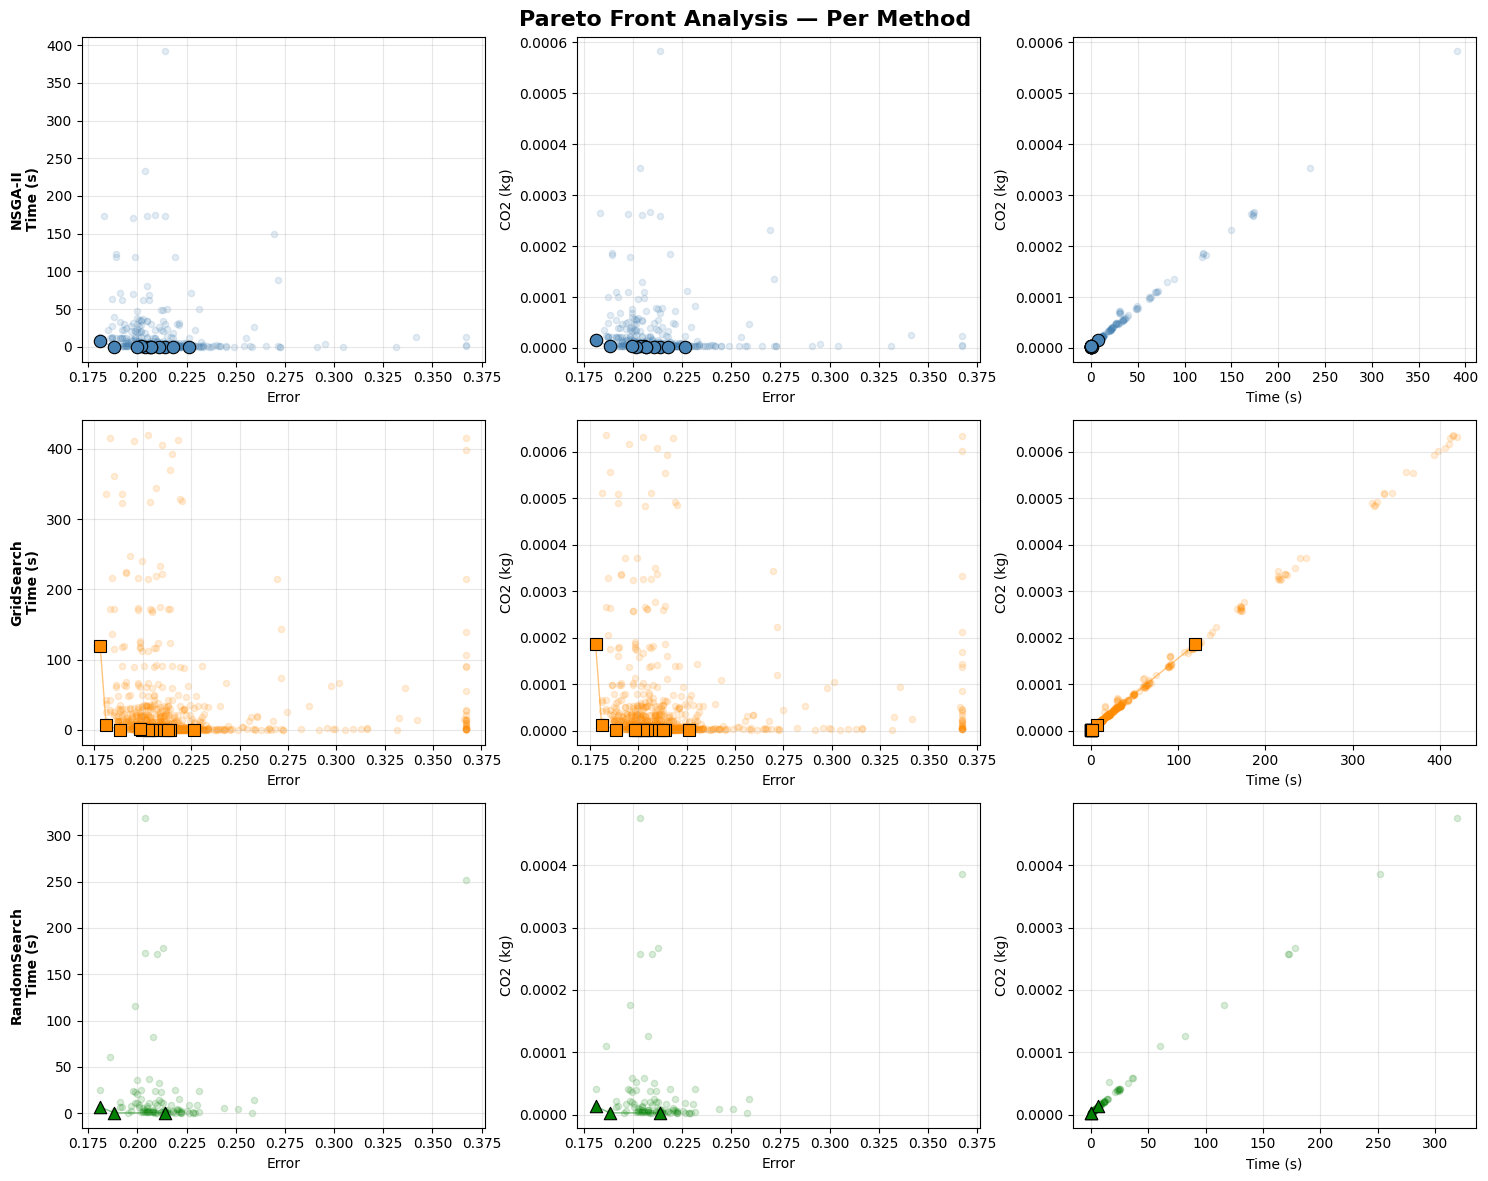

Saved: figs/pareto_per_method.png


In [13]:
os.makedirs('figs', exist_ok=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Pareto Front Analysis — Per Method', fontsize=16, fontweight='bold')

methods_data = [
    ('NSGA-II',      nsga_pareto_df, all_results,  'steelblue',  'o'),
    ('GridSearch',   grid_pareto_df, grid_results, 'darkorange', 's'),
    ('RandomSearch', rand_pareto_df, rand_results, 'green',      '^'),
]
pairs = [
    ('error', 'time_s', 'Error',    'Time (s)'),
    ('error', 'co2_kg', 'Error',    'CO2 (kg)'),
    ('time_s','co2_kg', 'Time (s)', 'CO2 (kg)'),
]

for row, (method_name, pareto_df, evals, color, marker) in enumerate(methods_data):
    eval_df = pd.DataFrame(evals)
    for col, (x_col, y_col, x_label, y_label) in enumerate(pairs):
        ax = axes[row][col]
        ax.scatter(eval_df[x_col], eval_df[y_col], alpha=0.15, s=20, color=color)
        ax.scatter(pareto_df[x_col], pareto_df[y_col],
                   alpha=1.0, s=80, color=color, marker=marker,
                   edgecolors='black', linewidths=0.8, zorder=5)
        sorted_p = pareto_df.sort_values(x_col)
        ax.plot(sorted_p[x_col], sorted_p[y_col], color=color, alpha=0.5, linewidth=1)
        ax.set_xlabel(x_label, fontsize=10)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(f'{method_name}\n{y_label}', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel(y_label, fontsize=10)

plt.tight_layout()
plt.savefig('figs/pareto_per_method.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figs/pareto_per_method.png')